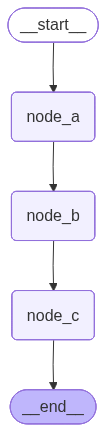

2026-07-11 11:26:53.635 | INFO     | __main__:<module>:49 - ==========-> 第一次执行 <-==========
2026-07-11 11:26:53.641 | INFO     | __main__:<module>:56 - 第一次执行结果：None
2026-07-11 11:26:53.641 | INFO     | __main__:<module>:58 - ==========-> 第二次执行 <-==========
2026-07-11 11:26:53.642 | INFO     | __main__:node_a:11 - node_a 被执行
2026-07-11 11:26:53.644 | INFO     | __main__:<module>:65 - 第二次执行结果：{'final_res': 'node_a 运行的中间结果'}
2026-07-11 11:26:53.645 | INFO     | __main__:<module>:67 - ==========-> 第三次执行 <-==========
2026-07-11 11:26:53.646 | INFO     | __main__:node_b:17 - node_b 被执行
2026-07-11 11:26:53.647 | INFO     | __main__:node_c:23 - node_c 被执行
2026-07-11 11:26:53.650 | INFO     | __main__:<module>:69 - 第三次执行结果：{'final_res': 'node_c 运行的中间结果'}
2026-07-11 11:26:53.651 | INFO     | __main__:<module>:71 - ==========-> 第四次执行 <-==========
2026-07-11 11:26:53.652 | INFO     | __main__:<module>:73 - 第四次执行结果：{'final_res': 'node_c 运行的中间结果'}
2026-07-11 11:26:53.653 | INFO     | __main__:<modul

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from loguru import logger

class OverAllState(TypedDict):
    final_res: str

def node_a(state: OverAllState) -> OverAllState:
    logger.info("node_a 被执行")
    return {
        "final_res": "node_a 运行的中间结果"
    }

def node_b(state: OverAllState) -> OverAllState:
    logger.info("node_b 被执行")
    return {
        "final_res": "node_b 运行的中间结果"
    }

def node_c(state: OverAllState) -> OverAllState:
    logger.info("node_c 被执行")
    return {
        "final_res": "node_c 运行的中间结果"
    }


builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_c")
builder.add_edge("node_c", END)

checkpointer = InMemorySaver()
graph = builder.compile(
    checkpointer=checkpointer
)

from IPython.display import display
display(graph)

config = {"configurable": {"thread_id": "123"}}

logger.info("{}-> 第一次执行 <-{}", "=" * 10, "=" * 10)
first_res = graph.invoke(
    {},
    config=config,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"]
)
logger.info("第一次执行结果：{}", first_res)

logger.info("{}-> 第二次执行 <-{}", "=" * 10, "=" * 10)
second_res = graph.invoke(
    None,
    config=config,
    interrupt_before=["node_a", "node_b"],
    interrupt_after=["node_a", "node_b"]
)
logger.info("第二次执行结果：{}", second_res)

logger.info("{}-> 第三次执行 <-{}", "=" * 10, "=" * 10)
third_res = graph.invoke(None, config=config)
logger.info("第三次执行结果：{}", third_res)

logger.info("{}-> 第四次执行 <-{}", "=" * 10, "=" * 10)
final_res = graph.invoke(None, config=config)
logger.info("第四次执行结果：{}", final_res)

logger.info("{}-> 完毕 <-{}", "=" * 10, "=" * 10)